# Task 1: Cross-Dataset Consistency Analysis (LINCS vs Tahoe)

This notebook demonstrates **Task 1** of the scGVP downstream analysis pipeline: validating model consistency across two independent perturbation datasets — **LINCS** and **Tahoe** — using three complementary strategies.

## Challenge
- LINCS uses `canonical_smiles` to identify drugs; Tahoe uses `sub_ptrb` (both are SMILES strings)
- Cell types differ between datasets (standard names vs. Cellosaurus IDs)
- Direct drug matching is non-trivial due to SMILES notation differences

## Three Validation Strategies

| Strategy | Approach | Key Metric |
|----------|----------|------------|
| **Strategy 1** | SMILES exact matching | Pearson / Spearman correlation |
| **Strategy 2** | Morgan fingerprint similarity (Tanimoto ≥ 0.85) | Correlation of structurally similar drug pairs |
| **Strategy 3** | Latent space alignment | KS statistic, Silhouette score, Centroid similarity |

## Workflow
1. Load model, LINCS dataset, and all 14 Tahoe plates
2. Process the LINCS reference dataset
3. Run Strategy 1 — SMILES exact match → per-sample Pearson/Spearman correlations
4. Run Strategy 2 — Morgan fingerprint similarity → cross-dataset prediction consistency
5. Run Strategy 3 — Latent space alignment → KS, Silhouette, centroid similarity
6. Comprehensive analysis combining all three strategies

## Outputs
- `cross_dataset_smiles_exact_all_samples.csv` — per-sample-pair correlations (Strategy 1)
- `cross_dataset_smiles_exact_avg.csv` — per-drug average correlations (Strategy 1)
- `cross_dataset_morgan_similarity.csv` — similar drug pair results (Strategy 2)
- `latent_alignment_per_plate.csv` — per-Tahoe-plate alignment metrics (Strategy 3)
- `latent_alignment_summary.csv` — aggregated alignment summary (Strategy 3)
- `all_metrics.json` — consolidated metrics across all strategies

## 1. Imports

In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

from model import GINVAE
from dataset import ChunkedGeneGraphDataset
from task1 import CrossDatasetConsistencyAnalysis

print(f"PyTorch: {torch.__version__}")
print(f"Device : {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch: 2.9.0.dev20250827+cu129
Device : cuda


## 2. Configuration

Update the paths below to match your local environment.  
Datasets and model weights are available at:  
**https://huggingface.co/datasets/Mike2481/Dataset4scGVP/tree/main**

In [11]:
# ── Paths ─────────────────────────────────────────────────────────────────────
MODEL_PATH  = '../src/best_gin_vae_model_node_level.pth'
LINCS_PATH  = '../lincs/merged_all_965_with_morgan.h5ad'
TAHOE_PATHS = [f'../minitahoe/p{i}_with_morgan.h5ad' for i in range(1, 15)]
REF_CACHE   = './output/reference_latents.pkl'
SAVE_DIR    = './output/task1_cross_dataset'

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs('./output', exist_ok=True)

# Number of Tahoe plates to load (set to e.g. 3 for a quick test)
N_PLATES = 14

## 3. Load Model

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = GINVAE(input_dim=1, hidden_dim=300, latent_dim=100, num_layers=2).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded on {device}")
print(f"Total parameters: {total_params:,}")

Model loaded on cuda
Total parameters: 728,604


## 4. Load LINCS Dataset

In [13]:
print("Loading LINCS dataset...")
lincs_adata = sc.read_h5ad(LINCS_PATH)

lincs_ptrb_mask = lincs_adata.obs['condition'] == 'perturb'
n_lincs_drugs = lincs_adata.obs.loc[lincs_ptrb_mask, 'canonical_smiles'].nunique()

print(f"LINCS: {lincs_adata.shape[0]} cells × {lincs_adata.shape[1]} genes")
print(f"Conditions : {lincs_adata.obs['condition'].value_counts().to_dict()}")
print(f"Unique drugs (canonical_smiles): {n_lincs_drugs}")

lincs_dataset = ChunkedGeneGraphDataset([LINCS_PATH], split='test')
print(f"Graph dataset samples: {len(lincs_dataset)}")

Loading LINCS dataset...
LINCS: 157138 cells × 965 genes
Conditions : {'control': 78569, 'perturb': 78569}
Unique drugs (canonical_smiles): 8316
Found 32 chunks with 157138 total samples
Graph dataset samples: 157138


## 5. Load Tahoe Dataset (14 Plates)

In [14]:
print(f"Loading {N_PLATES} Tahoe plates...")

tahoe_adatas   = []
tahoe_datasets = []

for i in range(N_PLATES):
    path  = TAHOE_PATHS[i]
    adata = sc.read_h5ad(path)
    dset  = ChunkedGeneGraphDataset([path], split='test')

    ptrb_mask = adata.obs['condition'] == 'perturb'
    n_drugs   = adata.obs.loc[ptrb_mask, 'sub_ptrb'].nunique()
    print(f"  P{i+1:2d}: {adata.shape[0]:6d} cells, {n_drugs:3d} unique drugs (sub_ptrb)")

    tahoe_adatas.append(adata)
    tahoe_datasets.append(dset)

all_tahoe_drugs = set()
for adata in tahoe_adatas:
    all_tahoe_drugs.update(
        adata.obs[adata.obs['condition'] == 'perturb']['sub_ptrb'].unique()
    )
print(f"\nTotal unique Tahoe drugs (all plates): {len(all_tahoe_drugs)}")

Loading 14 Tahoe plates...
Found 4 chunks with 39546 total samples
  P 1:  39546 cells,  91 unique drugs (sub_ptrb)
Found 4 chunks with 39546 total samples
  P 2:  39546 cells,  91 unique drugs (sub_ptrb)
Found 4 chunks with 39578 total samples
  P 3:  39578 cells,  91 unique drugs (sub_ptrb)
Found 4 chunks with 38722 total samples
  P 4:  38722 cells,  91 unique drugs (sub_ptrb)
Found 4 chunks with 38750 total samples
  P 5:  38750 cells,  91 unique drugs (sub_ptrb)
Found 4 chunks with 38728 total samples
  P 6:  38728 cells,  91 unique drugs (sub_ptrb)
Found 4 chunks with 37410 total samples
  P 7:  37410 cells,  86 unique drugs (sub_ptrb)
Found 4 chunks with 37460 total samples
  P 8:  37460 cells,  86 unique drugs (sub_ptrb)
Found 4 chunks with 37438 total samples
  P 9:  37438 cells,  86 unique drugs (sub_ptrb)
Found 4 chunks with 37872 total samples
  P10:  37872 cells,  89 unique drugs (sub_ptrb)
Found 4 chunks with 37876 total samples
  P11:  37876 cells,  89 unique drugs (sub_

## 6. Process Reference Dataset

The GINVAE model uses cached LINCS latent representations as the biological context reference for predicting perturbation effects.

In [15]:
print("Processing LINCS reference dataset (cached after first run)...")
model.process_reference_dataset(
    x_ref_dataset=lincs_dataset,
    save_path=REF_CACHE,
    force_reprocess=False   # Set True to recompute from scratch
)
print("Reference dataset ready.")

Processing LINCS reference dataset (cached after first run)...
Loading existing processed data from ./output/reference_latents.pkl
Loaded reference data metadata from ./output/reference_latents.pkl
Total samples available: 157138
Loading data from chunks...


Loading chunks: 100%|██████████| 16/16 [00:02<00:00,  6.42it/s, file=chunk_15.pkl]


Loaded and filtered 157138 samples from chunks
Computing biological context from 78569 control and 78569 perturb samples
Extracting graph-level latent representations...


Processing perturb samples: 100%|██████████| 78569/78569 [00:01<00:00, 54090.71it/s]


Computing mean representations...
References computed successfully.
Control ref shape: torch.Size([1, 100]), norm: 3.5154
perturb ref shape: torch.Size([1, 100]), norm: 3.5215
Biological context norm: 0.0068
Reference dataset ready.


## 7. Initialise CrossDatasetConsistencyAnalysis

In [16]:
task1 = CrossDatasetConsistencyAnalysis(model, device)
print("CrossDatasetConsistencyAnalysis initialised.")

CrossDatasetConsistencyAnalysis initialised.


## 8. Strategy 1 — SMILES Exact Matching

Find drugs with **identical** SMILES strings across LINCS and Tahoe.  
For each matched drug, compute Pearson and Spearman correlations between every LINCS sample and every Tahoe sample prediction, then save per-sample results and per-drug averages.

In [17]:
print("Running Strategy 1: SMILES Exact Matching...")

results_s1, common_smiles = task1.strategy1_smiles_exact_matching(
    lincs_adata=lincs_adata,
    tahoe_adatas=tahoe_adatas,
    lincs_test=lincs_dataset,
    tahoe_tests=tahoe_datasets,
    save_dir=SAVE_DIR
)

print(f"\nCommon drugs (exact SMILES match): {len(common_smiles)}")
print(f"Sample-pair comparisons         : {len(results_s1)}")
if len(results_s1) > 0:
    print(f"Mean Pearson  : {results_s1['pearson_correlation'].mean():.4f} "
          f"± {results_s1['pearson_correlation'].std():.4f}")
    print(f"Mean Spearman : {results_s1['spearman_correlation'].mean():.4f} "
          f"± {results_s1['spearman_correlation'].std():.4f}")

Running Strategy 1: SMILES Exact Matching...

Strategy 1: Cross-Dataset SMILES Exact Matching
LINCS: 8316 unique drugs (canonical_smiles)
Tahoe P1: 91 unique drugs (sub_ptrb)
Tahoe P2: 91 unique drugs (sub_ptrb)
Tahoe P3: 91 unique drugs (sub_ptrb)
Tahoe P4: 91 unique drugs (sub_ptrb)
Tahoe P5: 91 unique drugs (sub_ptrb)
Tahoe P6: 91 unique drugs (sub_ptrb)
Tahoe P7: 86 unique drugs (sub_ptrb)
Tahoe P8: 86 unique drugs (sub_ptrb)
Tahoe P9: 86 unique drugs (sub_ptrb)
Tahoe P10: 89 unique drugs (sub_ptrb)
Tahoe P11: 89 unique drugs (sub_ptrb)
Tahoe P12: 89 unique drugs (sub_ptrb)
Tahoe P13: 42 unique drugs (sub_ptrb)
Tahoe P14: 91 unique drugs (sub_ptrb)
Tahoe (all plates): 363 unique drugs

✓ Common drugs (exact SMILES match): 3
  Example matches:
    CC1CCC2CC(C(=CC=CC=CC(CC(C(=O)C(C(C(=CC(C(=O)CC(OC(=O)C3CCCC...
    COC(=O)C=CC(=O)OC...
    C1=CC2=NC=CC(=C2C=C1C=C3C(=O)NC(=O)S3)C4=CC=NC=C4...

Analyzing 3 matched drugs...


Processing matched drugs: 100%|██████████| 3/3 [00:19<00:00,  6.40s/it]


✓ Saved 225 sample pair correlations

Common drugs (exact SMILES match): 3
Sample-pair comparisons         : 225
Mean Pearson  : 0.5315 ± 0.0634
Mean Spearman : 0.5751 ± 0.0270


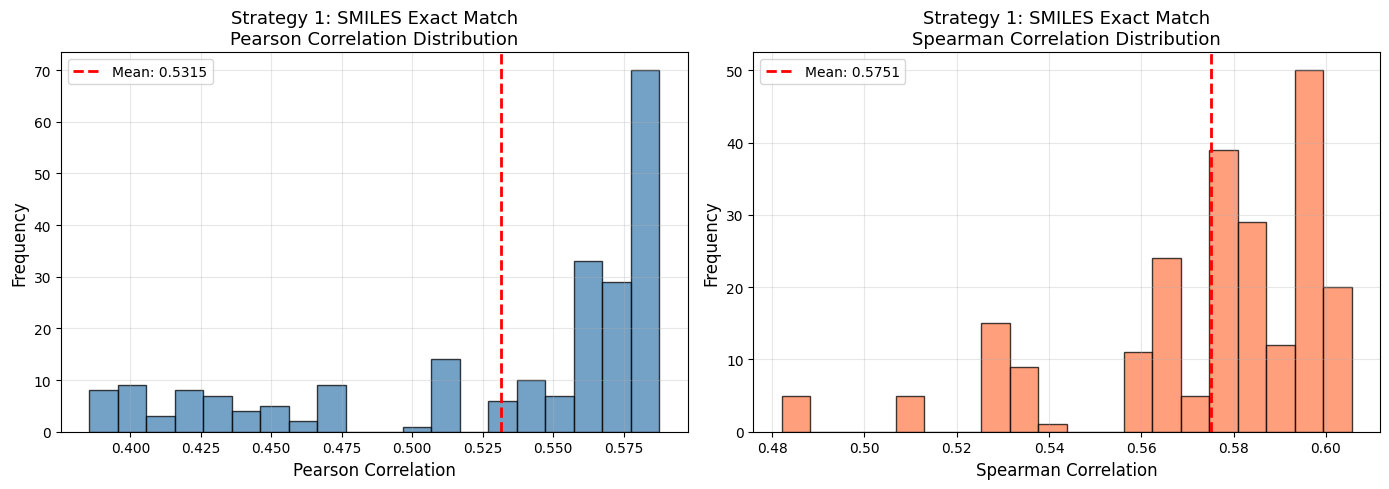


Per-drug average correlations:


,drug_smiles,dataset1,dataset2,pearson_correlation,spearman_correlation
0,C1=CC2=NC=CC(=C2C=C1C=C3C(=O)NC(=O)S3)C4=CC=NC=C4,LINCS,Tahoe_P1,0.580184,0.597704
1,C1=CC2=NC=CC(=C2C=C1C=C3C(=O)NC(=O)S3)C4=CC=NC=C4,LINCS,Tahoe_P2,0.500313,0.559797
2,C1=CC2=NC=CC(=C2C=C1C=C3C(=O)NC(=O)S3)C4=CC=NC=C4,LINCS,Tahoe_P3,0.543352,0.570333
3,CC1CCC2CC(C(=CC=CC=CC(CC(C(=O)C(C(C(=CC(C(=O)C...,LINCS,Tahoe_P1,0.581076,0.596892
4,CC1CCC2CC(C(=CC=CC=CC(CC(C(=O)C(C(C(=CC(C(=O)C...,LINCS,Tahoe_P2,0.523719,0.570767
5,CC1CCC2CC(C(=CC=CC=CC(CC(C(=O)C(C(C(=CC(C(=O)C...,LINCS,Tahoe_P3,0.539073,0.561346
6,COC(=O)C=CC(=O)OC,LINCS,Tahoe_P7,0.581344,0.563464
7,COC(=O)C=CC(=O)OC,LINCS,Tahoe_P8,0.417470,0.556423
8,COC(=O)C=CC(=O)OC,LINCS,Tahoe_P9,0.517034,0.599566


In [18]:
# Visualise Strategy 1 results
if len(results_s1) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, col, color, label in zip(
        axes,
        ['pearson_correlation', 'spearman_correlation'],
        ['steelblue', 'coral'],
        ['Pearson Correlation', 'Spearman Correlation']
    ):
        mean_val = results_s1[col].mean()
        ax.hist(results_s1[col], bins=20, color=color, alpha=0.75, edgecolor='black')
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {mean_val:.4f}')
        ax.set_xlabel(label, fontsize=12)
        ax.set_ylabel('Frequency', fontsize=12)
        ax.set_title(f'Strategy 1: SMILES Exact Match\n{label} Distribution', fontsize=13)
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'strategy1_correlations.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # Load averaged results
    avg_path = os.path.join(SAVE_DIR, 'cross_dataset_smiles_exact_avg.csv')
    if os.path.exists(avg_path):
        avg_df = pd.read_csv(avg_path)
        print("\nPer-drug average correlations:")
        display(avg_df)
else:
    print("No exact SMILES matches found.\n"
          "LINCS and Tahoe use different chemical libraries — "
          "Strategies 2 & 3 provide the main cross-dataset validation.")

## 9. Strategy 2 — Morgan Fingerprint Similarity Matching

When SMILES strings don't match exactly, **Tanimoto similarity** on Morgan fingerprints is used to find structurally similar drugs (threshold ≥ 0.85). Similar drug pairs should produce similar predicted expression profiles if the model generalises well.

In [19]:
print("Running Strategy 2: Morgan Fingerprint Similarity Matching...")

results_s2 = task1.strategy2_morgan_fingerprint_similarity(
    lincs_adata=lincs_adata,
    tahoe_adatas=tahoe_adatas,
    lincs_test=lincs_dataset,
    tahoe_tests=tahoe_datasets,
    save_dir=SAVE_DIR,
    similarity_threshold=0.85
)

if len(results_s2) > 0:
    print(f"\nSimilar drug pairs found   : {len(results_s2)}")
    print(f"Mean chemical similarity   : {results_s2['chemical_similarity'].mean():.4f}")
    print(f"Mean Pearson correlation   : {results_s2['pearson_correlation'].mean():.4f} "
          f"± {results_s2['pearson_correlation'].std():.4f}")
    print(f"Mean Spearman correlation  : {results_s2['spearman_correlation'].mean():.4f} "
          f"± {results_s2['spearman_correlation'].std():.4f}")
else:
    print("No similar drug pairs found at threshold 0.85, "
          "or Morgan fingerprints not available in the dataset.")

Running Strategy 2: Morgan Fingerprint Similarity Matching...

Strategy 2: Morgan Fingerprint Similarity Matching
Using similarity threshold: 0.85
Sampled 50 LINCS drugs
Collected 1204 unique Tahoe drugs

Finding similar drug pairs...


Matching drugs: 100%|██████████| 50/50 [00:04<00:00, 10.20it/s]



✓ Found 17 similar drug pairs (similarity ≥ 0.85)


Analyzing similar pairs: 100%|██████████| 17/17 [00:03<00:00,  5.14it/s]


Similar drug pairs found   : 17
Mean chemical similarity   : 0.9450
Mean Pearson correlation   : 0.5175 ± 0.0666
Mean Spearman correlation  : 0.5870 ± 0.0291


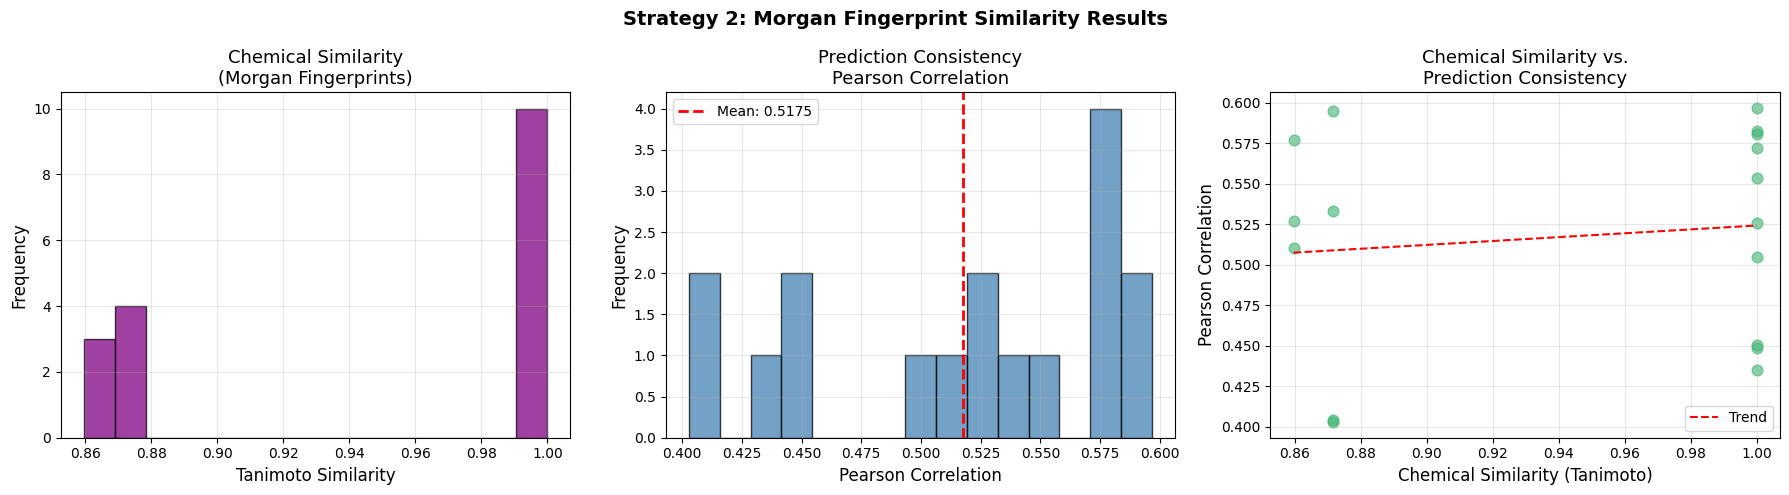


Top matched pairs (highest chemical similarity):


,lincs_drug,tahoe_drug,chemical_similarity,pearson_correlation,spearman_correlation
0,CO[C@H]1C=CO[C@@]2(C)Oc3c(C2=O)c2c4nc5cc,CC1C=CC=C(C(=O)NC2=C(C3=C(C4=C(C(=C3O)C),1.0,0.582586,0.564452
1,CO[C@H]1C=CO[C@@]2(C)Oc3c(C2=O)c2c4nc5cc,CC1C=CC=C(C(=O)NC2=C(C3=C(C4=C(C(=C3O)C),1.0,0.504545,0.600643
2,CO[C@H]1C=CO[C@@]2(C)Oc3c(C2=O)c2c4nc5cc,CC1C=CC=C(C(=O)NC2=C(C3=C(C4=C(C(=C3O)C),1.0,0.553554,0.605339
3,CC(C)NC[C@@H](C(=O)N1CCN(CC1)c1ncnc2[C@@,CC1CC(C2=C1C(=NC=N2)N3CCN(CC3)C(=O)C(CNC,1.0,0.580626,0.597328
4,CC(C)NC[C@@H](C(=O)N1CCN(CC1)c1ncnc2[C@@,CC1CC(C2=C1C(=NC=N2)N3CCN(CC3)C(=O)C(CNC,1.0,0.450136,0.497532
5,CC(C)NC[C@@H](C(=O)N1CCN(CC1)c1ncnc2[C@@,CC1CC(C2=C1C(=NC=N2)N3CCN(CC3)C(=O)C(CNC,1.0,0.525486,0.579869
10,COC1CC(CC(C)C2CC(=O)C(C)C=C(C)C(O)C(OC)C,CC1CCC2CC(C(=CC=CC=CC(CC(C(=O)C(C(C(=CC(,1.0,0.434929,0.569662
12,COC1CC(CC(C)C2CC(=O)C(C)C=C(C)C(O)C(OC)C,CC1CCC2CC(C(=CC=CC=CC(CC(C(=O)C(C(C(=CC(,1.0,0.572102,0.613308
14,COC1CC(CC(C)C2CC(=O)C(C)C=C(C)C(O)C(OC)C,CC1CCC2CC(C(=CC=CC=CC(CC(C(=O)C(C(C(=CC(,1.0,0.596731,0.613880
15,COC1CC(CC(C)C2CC(=O)C(C)C=C(C)C(O)C(OC)C,CC1CCC2CC(C(=CC=CC=CC(CC(C(=O)C(C(C(=CC(,1.0,0.448781,0.569731


In [20]:
if len(results_s2) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Chemical similarity distribution
    axes[0].hist(results_s2['chemical_similarity'], bins=15,
                 color='purple', alpha=0.75, edgecolor='black')
    axes[0].set_xlabel('Tanimoto Similarity', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Chemical Similarity\n(Morgan Fingerprints)', fontsize=13)
    axes[0].grid(alpha=0.3)

    # Pearson correlation distribution
    axes[1].hist(results_s2['pearson_correlation'], bins=15,
                 color='steelblue', alpha=0.75, edgecolor='black')
    axes[1].axvline(results_s2['pearson_correlation'].mean(), color='red',
                    linestyle='--', linewidth=2,
                    label=f"Mean: {results_s2['pearson_correlation'].mean():.4f}")
    axes[1].set_xlabel('Pearson Correlation', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].set_title('Prediction Consistency\nPearson Correlation', fontsize=13)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Chemical similarity vs. prediction correlation scatter
    axes[2].scatter(results_s2['chemical_similarity'],
                    results_s2['pearson_correlation'],
                    alpha=0.6, color='mediumseagreen', s=60)
    if len(results_s2) > 2:
        z = np.polyfit(results_s2['chemical_similarity'],
                       results_s2['pearson_correlation'], 1)
        x_line = np.linspace(results_s2['chemical_similarity'].min(),
                             results_s2['chemical_similarity'].max(), 50)
        axes[2].plot(x_line, np.poly1d(z)(x_line), 'r--', lw=1.5, label='Trend')
        axes[2].legend()
    axes[2].set_xlabel('Chemical Similarity (Tanimoto)', fontsize=12)
    axes[2].set_ylabel('Pearson Correlation', fontsize=12)
    axes[2].set_title('Chemical Similarity vs.\nPrediction Consistency', fontsize=13)
    axes[2].grid(alpha=0.3)

    plt.suptitle('Strategy 2: Morgan Fingerprint Similarity Results', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'strategy2_similarity.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print("\nTop matched pairs (highest chemical similarity):")
    display(results_s2.nlargest(10, 'chemical_similarity')[
        ['lincs_drug', 'tahoe_drug', 'chemical_similarity',
         'pearson_correlation', 'spearman_correlation']
    ])

## 10. Strategy 3 — Latent Space Alignment

Compares the **raw expression space** vs. the **model's latent space** for LINCS and each Tahoe plate. Three metrics are computed per plate:

| Metric | Direction | Interpretation |
|--------|-----------|----------------|
| **KS statistic** | ↓ better | Distributional distance between datasets |
| **Silhouette score** | ↓ better | Batch effect separation (lower = better mixed) |
| **Centroid similarity** | ↑ better | Cosine similarity between dataset centroids |

> **Note**: This strategy processes **all** samples and may take significant time.

In [21]:
print("Running Strategy 3: Latent Space Alignment...")
print("(Processes all samples — may take a while on large datasets)")

results_s3 = task1.strategy3_latent_space_alignment(
    lincs_adata=lincs_adata,
    tahoe_adatas=tahoe_adatas,
    lincs_test=lincs_dataset,
    tahoe_tests=tahoe_datasets,
    save_dir=SAVE_DIR
)

if results_s3:
    print(f"\n=== Latent Alignment Summary ===")
    print(f"LINCS samples    : {results_s3.get('lincs_samples', 0)}")
    print(f"Tahoe samples    : {results_s3.get('total_tahoe_samples', 0)}")
    print(f"Plates analysed  : {results_s3.get('n_plates', 0)}")
    n = results_s3.get('n_plates', 0)
    print(f"\nKS Statistic  (↓ better)")
    print(f"  Raw    : {results_s3.get('ks_raw_mean', 0):.4f}")
    print(f"  Latent : {results_s3.get('ks_latent_mean', 0):.4f}")
    print(f"  Improved plates: {results_s3.get('ks_improved_count', 0)}/{n}")
    print(f"\nSilhouette (↓ better)")
    print(f"  Raw    : {results_s3.get('silhouette_raw_mean', 0):.4f}")
    print(f"  Latent : {results_s3.get('silhouette_latent_mean', 0):.4f}")
    print(f"  Improved plates: {results_s3.get('silhouette_improved_count', 0)}/{n}")
    print(f"\nCentroid Similarity (↑ better)")
    print(f"  Raw    : {results_s3.get('centroid_sim_raw_mean', 0):.4f}")
    print(f"  Latent : {results_s3.get('centroid_sim_latent_mean', 0):.4f}")
    print(f"  Improved plates: {results_s3.get('centroid_sim_improved_count', 0)}/{n}")

Running Strategy 3: Latent Space Alignment...
(Processes all samples — may take a while on large datasets)

Strategy 3: Cross-Dataset Latent Space Alignment (Full Data)

[Part 1] Collecting ALL LINCS samples as reference...


  Collected 157138 / 157138 LINCS samples (full data)

[Part 2] Computing metrics for each Tahoe plate (full data)...
  Processing P1 (39546 samples)...


    Collected 20000 / 39546 samples
    KS: 0.9988 → 0.9814 (Δ=+0.0173)
    Silhouette: 0.9092 → 0.8786 (Δ=+0.0306)
    Centroid Sim: 0.4898 → 0.8449 (Δ=+0.3551)
  Processing P2 (39546 samples)...


    Collected 20000 / 39546 samples
    KS: 0.9995 → 0.9789 (Δ=+0.0206)
    Silhouette: 0.9394 → 0.9115 (Δ=+0.0279)
    Centroid Sim: 0.4526 → 0.6847 (Δ=+0.2320)
  Processing P3 (39578 samples)...


    Collected 20000 / 39578 samples
    KS: 0.9998 → 0.9683 (Δ=+0.0316)
    Silhouette: 0.9301 → 0.8851 (Δ=+0.0450)
    Centroid Sim: 0.4089 → 0.5208 (Δ=+0.1119)
  Processing P4 (38722 samples)...


...

    Collected 20000 / 37872 samples
    KS: 0.9999 → 0.9809 (Δ=+0.0190)
    Silhouette: 0.9389 → 0.9687 (Δ=-0.0298)
    Centroid Sim: 0.4641 → 0.1543 (Δ=-0.3098)
  Processing P11 (37876 samples)...


    Collected 20000 / 37876 samples
    KS: 0.9992 → 0.9836 (Δ=+0.0156)
    Silhouette: 0.9520 → 0.9047 (Δ=+0.0473)
    Centroid Sim: 0.4040 → 0.7012 (Δ=+0.2972)
  Processing P12 (37868 samples)...


    Collected 20000 / 37868 samples
    KS: 0.9995 → 0.9877 (Δ=+0.0118)
    Silhouette: 0.9347 → 0.9101 (Δ=+0.0245)
    Centroid Sim: 0.4327 → 0.8281 (Δ=+0.3954)
  Processing P13 (38712 samples)...


    Collected 20000 / 38712 samples
    KS: 0.9996 → 0.9811 (Δ=+0.0185)
    Silhouette: 0.9285 → 0.9070 (Δ=+0.0214)
    Centroid Sim: 0.4328 → 0.7132 (Δ=+0.2805)
  Processing P14 (38706 samples)...


    Collected 20000 / 38706 samples
    KS: 0.9998 → 0.9763 (Δ=+0.0236)
    Silhouette: 0.9241 → 0.9429 (Δ=-0.0188)
    Centroid Sim: 0.4480 → 0.3826 (Δ=-0.0654)

[Part 3] Summary Statistics...

------------------------------------------------------------
Cross-Dataset Alignment Summary (Full Data)
------------------------------------------------------------
LINCS samples: 157138
Total Tahoe samples: 280000
Plates analyzed: 14

KS Statistic (↓ better = more similar distributions):
  Raw: 0.9996, Latent: 0.9800
  Improved plates: 14/14

Silhouette (↓ better = less batch effect):
  Raw: 0.9335, Latent: 0.9134
  Improved plates: 10/14

Centroid Similarity (↑ better = more aligned centroids):
  Raw: 0.4389, Latent: 0.5903
  Improved plates: 10/14
------------------------------------------------------------

=== Latent Alignment Summary ===
LINCS samples    : 157138
Tahoe samples    : 280000
Plates analysed  : 14

KS Statistic  (↓ better)
  Raw    : 0.9996
  Latent : 0.9800
  Improved plate

Per-plate metrics (14 plates):


,plate,ks_raw,ks_latent,ks_improvement,silhouette_raw,silhouette_latent,silhouette_improvement,centroid_sim_raw,centroid_sim_latent,centroid_sim_improvement,n_samples
0,P1,0.998756,0.981440,0.017317,0.909200,0.878570,0.030629,0.489775,0.844906,0.355130,20000
1,P2,0.999481,0.978870,0.020611,0.939442,0.911506,0.027936,0.452635,0.684677,0.232042,20000
2,P3,0.999846,0.968282,0.031563,0.930077,0.885054,0.045023,0.408898,0.520810,0.111913,20000
3,P4,0.999436,0.983584,0.015852,0.949866,0.914922,0.034944,0.420739,0.718288,0.297549,20000
4,P5,0.999854,0.974787,0.025067,0.930092,0.945116,-0.015024,0.457694,0.273818,-0.183876,20000
5,P6,0.999539,0.982634,0.016905,0.927496,0.879257,0.048239,0.436592,0.836630,0.400038,20000
6,P7,0.999891,0.976542,0.023349,0.925918,0.931472,-0.005554,0.449083,0.123342,-0.325741,20000
7,P8,0.999716,0.982831,0.016885,0.930788,0.903434,0.027354,0.438188,0.789495,0.351306,20000
8,P9,0.999423,0.981224,0.018199,0.947373,0.904891,0.042482,0.409444,0.693458,0.284015,20000
9,P10,0.999882,0.980917,0.018965,0.938910,0.968713,-0.029804,0.464093,0.154291,-0.309802,20000


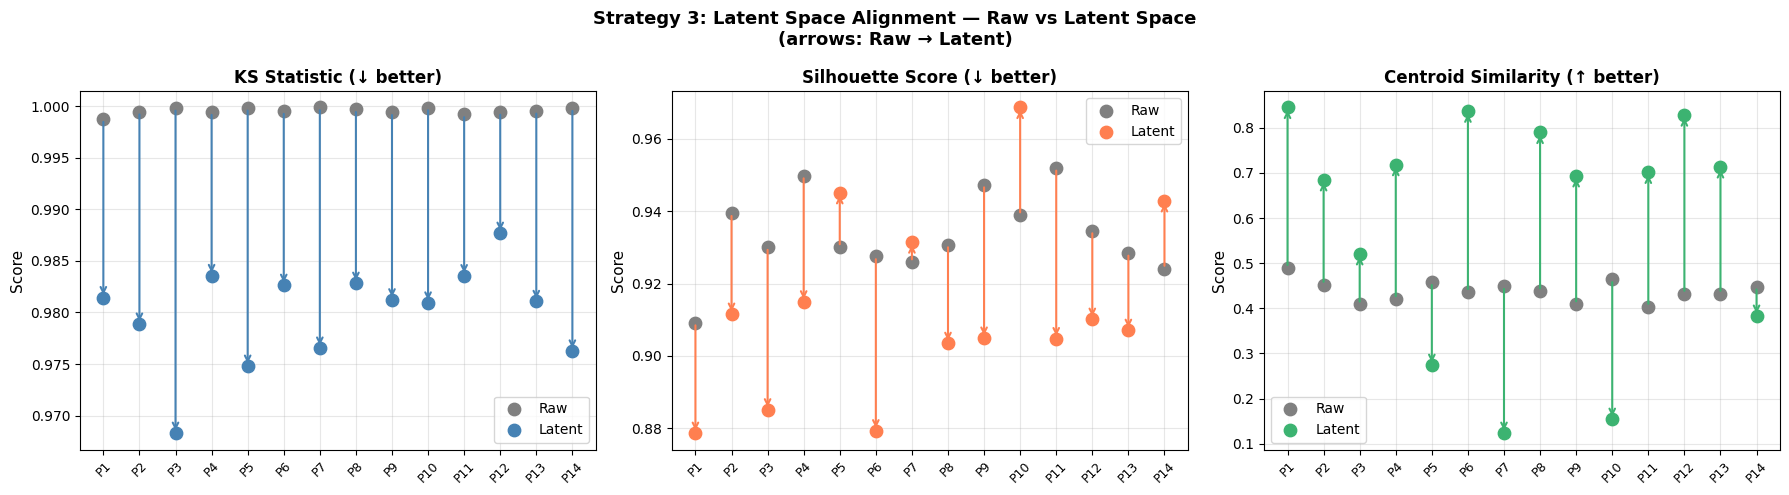

In [22]:
# Per-plate arrow plot: Raw → Latent
per_plate_path = os.path.join(SAVE_DIR, 'latent_alignment_per_plate.csv')

if os.path.exists(per_plate_path):
    metrics_df = pd.read_csv(per_plate_path)
    print(f"Per-plate metrics ({len(metrics_df)} plates):")
    display(metrics_df)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metric_triples = [
        ('ks_raw', 'ks_latent',
         'KS Statistic (↓ better)', 'steelblue'),
        ('silhouette_raw', 'silhouette_latent',
         'Silhouette Score (↓ better)', 'coral'),
        ('centroid_sim_raw', 'centroid_sim_latent',
         'Centroid Similarity (↑ better)', 'mediumseagreen'),
    ]

    for ax, (raw_col, lat_col, title, color) in zip(axes, metric_triples):
        x = np.arange(len(metrics_df))
        ax.scatter(x, metrics_df[raw_col], s=80, color='gray',  label='Raw',    zorder=3)
        ax.scatter(x, metrics_df[lat_col], s=80, color=color, label='Latent', zorder=3)
        for i in range(len(metrics_df)):
            ax.annotate('',
                        xy=(i, metrics_df[lat_col].iloc[i]),
                        xytext=(i, metrics_df[raw_col].iloc[i]),
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
        ax.set_xticks(x)
        ax.set_xticklabels(metrics_df['plate'], rotation=45, fontsize=9)
        ax.set_ylabel('Score', fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle('Strategy 3: Latent Space Alignment — Raw vs Latent Space\n'
                 '(arrows: Raw → Latent)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'strategy3_alignment.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Per-plate CSV not found — Strategy 3 may not have produced results yet.")

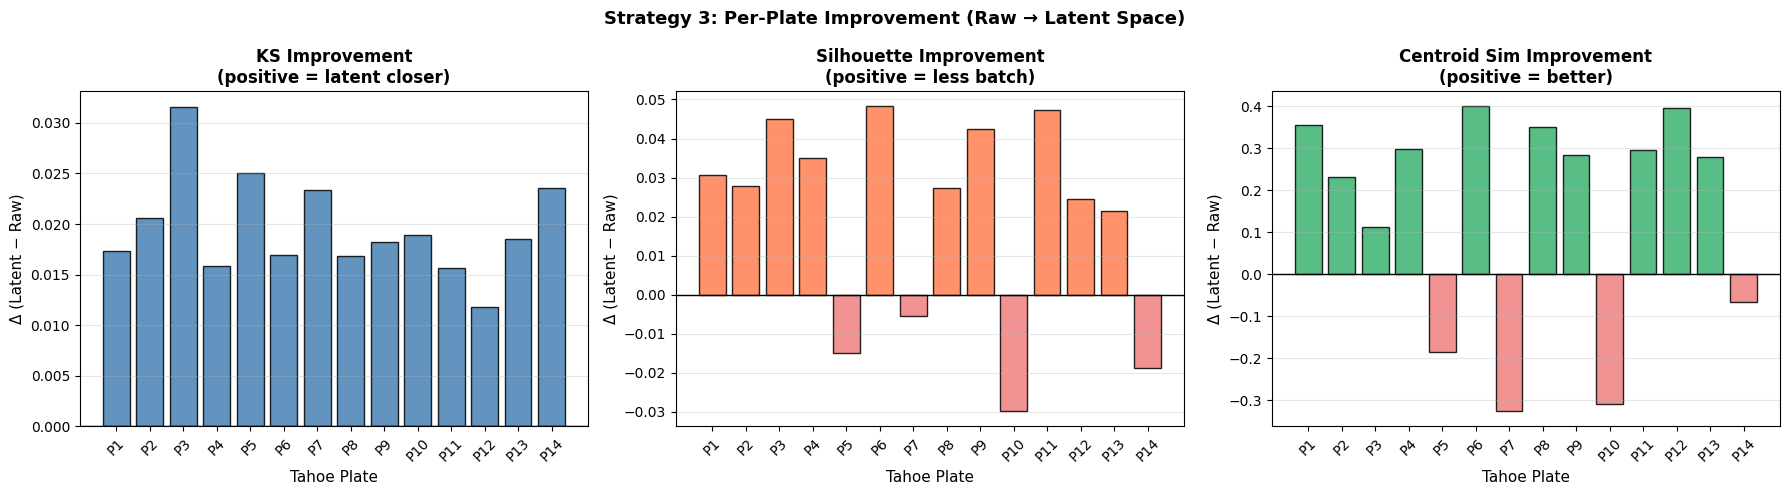

In [23]:
# Improvement bar chart per plate
if os.path.exists(per_plate_path):
    metrics_df = pd.read_csv(per_plate_path)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    improvement_info = [
        ('ks_improvement',           'KS Improvement\n(positive = latent closer)',    'steelblue'),
        ('silhouette_improvement',   'Silhouette Improvement\n(positive = less batch)', 'coral'),
        ('centroid_sim_improvement', 'Centroid Sim Improvement\n(positive = better)',  'mediumseagreen'),
    ]

    for ax, (col, title, color) in zip(axes, improvement_info):
        vals = metrics_df[col]
        bar_colors = [color if v > 0 else 'lightcoral' for v in vals]
        ax.bar(metrics_df['plate'], vals, color=bar_colors, alpha=0.85, edgecolor='black')
        ax.axhline(0, color='black', linewidth=1)
        ax.set_xlabel('Tahoe Plate', fontsize=11)
        ax.set_ylabel('Δ (Latent − Raw)', fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Strategy 3: Per-Plate Improvement (Raw → Latent Space)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'strategy3_improvement.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 11. Summary Dashboard

In [1]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Strategy 1 ───────────────────────────────────────────────────────────────
ax = axes[0]
if len(results_s1) > 0:
    vals = {'Pearson': results_s1['pearson_correlation'].mean(),
            'Spearman': results_s1['spearman_correlation'].mean()}
    bars = ax.bar(vals.keys(), vals.values(),
                  color=['steelblue', 'coral'], alpha=0.85, edgecolor='black')
    for bar, v in zip(bars, vals.values()):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.4f}', ha='center', fontsize=11)
    ax.set_ylim(0, 1)
else:
    ax.text(0.5, 0.5, 'No exact SMILES\nmatches found',
            ha='center', va='center', transform=ax.transAxes,
            fontsize=12, color='gray')
ax.set_ylabel('Correlation', fontsize=12)
ax.set_title(f'Strategy 1: SMILES Exact Match\n({len(common_smiles)} common drugs)', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# ── Strategy 2 ───────────────────────────────────────────────────────────────
ax = axes[1]
if len(results_s2) > 0:
    vals = {'Pearson': results_s2['pearson_correlation'].mean(),
            'Spearman': results_s2['spearman_correlation'].mean()}
    bars = ax.bar(vals.keys(), vals.values(),
                  color=['steelblue', 'coral'], alpha=0.85, edgecolor='black')
    for bar, v in zip(bars, vals.values()):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.4f}', ha='center', fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_title(f'Strategy 2: Morgan FP Similarity\n({len(results_s2)} similar pairs)', fontsize=12)
else:
    ax.text(0.5, 0.5, 'No similar\ndrug pairs found',
            ha='center', va='center', transform=ax.transAxes,
            fontsize=12, color='gray')
    ax.set_title('Strategy 2: Morgan FP Similarity', fontsize=12)
ax.set_ylabel('Correlation', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# ── Strategy 3 ───────────────────────────────────────────────────────────────
ax = axes[2]
if results_s3:
    metric_names = ['KS Stat', 'Silhouette', 'Centroid Sim']
    raw_vals    = [results_s3.get('ks_raw_mean', 0),
                   results_s3.get('silhouette_raw_mean', 0),
                   results_s3.get('centroid_sim_raw_mean', 0)]
    latent_vals = [results_s3.get('ks_latent_mean', 0),
                   results_s3.get('silhouette_latent_mean', 0),
                   results_s3.get('centroid_sim_latent_mean', 0)]
    x = np.arange(len(metric_names))
    w = 0.35
    ax.bar(x - w/2, raw_vals,    w, label='Raw',    color='gray',      alpha=0.85)
    ax.bar(x + w/2, latent_vals, w, label='Latent', color='steelblue', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_names, fontsize=11)
    ax.legend()
    ax.set_title(f'Strategy 3: Latent Alignment\n({results_s3.get("n_plates", 0)} plates)', fontsize=12)
else:
    ax.text(0.5, 0.5, 'Strategy 3\nresults not available',
            ha='center', va='center', transform=ax.transAxes,
            fontsize=12, color='gray')
    ax.set_title('Strategy 3: Latent Alignment', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cross-Dataset Consistency Analysis — Summary Dashboard\n(LINCS vs Tahoe)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'summary_dashboard.png'), dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'plt' is not defined

## 12. Final Summary

In [2]:
print("=" * 70)
print("Task 1: Cross-Dataset Consistency Analysis — Final Summary")
print("=" * 70)
print(f"\n[Dataset Overview]")
print(f"  LINCS unique drugs  : {n_lincs_drugs}")
print(f"  Tahoe unique drugs  : {len(all_tahoe_drugs)}")

print(f"\n[Strategy 1 — SMILES Exact Match]")
print(f"  Common drugs        : {len(common_smiles)}")
if len(results_s1) > 0:
    print(f"  Sample comparisons  : {len(results_s1)}")
    print(f"  Mean Pearson        : {results_s1['pearson_correlation'].mean():.4f}")
    print(f"  Mean Spearman       : {results_s1['spearman_correlation'].mean():.4f}")
else:
    print("  No exact matches found")

print(f"\n[Strategy 2 — Morgan Fingerprint Similarity]")
if len(results_s2) > 0:
    print(f"  Similar pairs       : {len(results_s2)}")
    print(f"  Mean similarity     : {results_s2['chemical_similarity'].mean():.4f}")
    print(f"  Mean Pearson        : {results_s2['pearson_correlation'].mean():.4f}")
else:
    print("  No similar pairs found at threshold 0.85")

print(f"\n[Strategy 3 — Latent Space Alignment]")
if results_s3:
    n = results_s3.get('n_plates', 0)
    print(f"  Plates analysed     : {n}")
    print(f"  KS  (raw→latent)    : {results_s3.get('ks_raw_mean',0):.4f} → {results_s3.get('ks_latent_mean',0):.4f}  "
          f"({results_s3.get('ks_improved_count',0)}/{n} plates improved)")
    print(f"  Sil (raw→latent)    : {results_s3.get('silhouette_raw_mean',0):.4f} → {results_s3.get('silhouette_latent_mean',0):.4f}  "
          f"({results_s3.get('silhouette_improved_count',0)}/{n} plates improved)")
    print(f"  Cen (raw→latent)    : {results_s3.get('centroid_sim_raw_mean',0):.4f} → {results_s3.get('centroid_sim_latent_mean',0):.4f}  "
          f"({results_s3.get('centroid_sim_improved_count',0)}/{n} plates improved)")
else:
    print("  Results not available")

print(f"\nAll outputs saved to: {SAVE_DIR}")

Task 1: Cross-Dataset Consistency Analysis — Final Summary

[Dataset Overview]


NameError: name 'n_lincs_drugs' is not defined